# Experiment 2b: AISO 클러스터링 — 합성 Gaussian 데이터 (K=N_CLUSTERS)

## 목적
Iris/Wine에서 Type Collapse로 bilinear가 실패하는 근본 원인 규명.
**합성 데이터**로 cluster separation을 직접 제어하면서 AISO 클러스터링의 이론적 한계 확인.

### 핵심 수정: K = N_CLUSTERS (이전: K = D)
- W 벡터 차원 = 클러스터 수 → W_i가 "클러스터 소속 확률"처럼 동작할 수 있음
- W-space repulsion: BETA_REP으로 W 다양성 강제 유지
- 3가지 데이터 설정: 고분리 / 중간 / 저분리 blob

### Phase 3 방법 4종
| 방법 | 설명 |
|------|------|
| Euclidean | proto_X까지 L2 거리 |
| Bilinear-Nearest | 가장 가까운 앵커 W 사용 |
| Bilinear-Smooth | soft-distance 가중 W 보간 (temp=0.3) |
| W-Direct | K=N_CLUSTERS일 때 argmax(W_j) — W 자체가 클러스터 할당 |


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from itertools import permutations
import warnings; warnings.filterwarnings("ignore")

# ── 합성 데이터 3가지 설정 ──
SEED_DATA = 0
N_CLUSTERS = 3
SETTINGS = {
    'high-sep (std=0.5)':  0.5,
    'mid-sep  (std=1.0)':  1.0,
    'low-sep  (std=1.8)':  1.8,
}

def make_dataset(std, D=10, n_per=100, seed=SEED_DATA):
    X_raw, y = make_blobs(n_samples=n_per*N_CLUSTERS, n_features=D,
                          centers=N_CLUSTERS, cluster_std=std, random_state=seed)
    X = MinMaxScaler().fit_transform(X_raw)
    return X, y

# 기본 mid-sep으로 확인
X, y_true = make_dataset(1.0)
N, D = X.shape
km_base = KMeans(N_CLUSTERS, random_state=42, n_init=10).fit(X)
ARI_KM  = adjusted_rand_score(y_true, km_base.labels_)
print(f"데이터: N={N} D={D} K={N_CLUSTERS}")
print(f"K-Means 기준 (mid-sep): ARI={ARI_KM:.4f}")


데이터: N=300 D=10 K=3
K-Means 기준 (mid-sep): ARI=1.0000


## AISO Core: K = N_CLUSTERS 설정

핵심 변경점:
- `K = N_CLUSTERS = 3` (W 차원 = 클러스터 수)
- `BETA_REP`: W-space 척력 — 가장 척력이 강한 에이전트 W에서 멀어짐
- 수렴 후 `argmax(W_i) ≈ 클러스터 소속`이 되면 W-Direct 방식 성공


In [18]:
def run_aiso(X, y_true, SEED=42, N_AG=15, N_IT=400,
             ALPHA=0.3, BETA=0.08, M_LOW=-2.0, W_REPEL=2.0,
             LAMBDA=0.05, temp=0.3, verbose=True):
    """
    K = N_CLUSTERS AISO 클러스터링.
    LAMBDA: mean-field W 척력 강도 (0=off). W_new += LAMBDA*(W_new - W_mean)
      → 기존 차이를 증폭, uniform 수렴 방지. (이전 BETA_REP는 uniform-subtract로 무력화됨)
    반환: preds dict {method: ARI}, diagnostics dict
    """
    rng = np.random.RandomState(SEED)
    n, d = X.shape
    N_CLUSTERS = 3
    K = N_CLUSTERS  # KEY: W dimension = cluster count

    # ── 초기화 ──
    init_idx = rng.choice(n, N_AG, replace=False)
    X_ag  = X[init_idx].copy()
    W_ag  = rng.dirichlet(np.ones(K), N_AG)   # simplex (K=3)
    M     = rng.uniform(M_LOW, W_REPEL, (K, K))

    # ── Phase 1: 밀도 탐색 + W 업데이트 ──
    div_log, went_log = [], []
    for t in range(N_IT):
        C = W_ag @ M @ W_ag.T
        np.fill_diagonal(C, 0)
        W_mean = W_ag.mean(0)  # mean-field 기준점 (매 iter 재계산)

        for i in range(N_AG):
            ci = C[i].copy(); ci[i] = 0
            att = np.argsort(ci)[-3:]
            rep = np.argsort(ci)[:3]

            Fv = (sum(ci[j] * (X_ag[j] - X_ag[i]) for j in att) +
                  W_REPEL * sum(ci[j] * (X_ag[j] - X_ag[i]) for j in rep)) / 6.0

            candidate = np.clip(X_ag[i] + ALPHA * Fv, 0, 1)
            nn = np.argmin(np.linalg.norm(X - candidate, axis=1))
            X_ag[i] = X[nn]

            # W 인력 (가장 호환되는 에이전트로 동화)
            bj = att[np.argmax(ci[att])]
            W_new = (1 - BETA) * W_ag[i] + BETA * W_ag[bj]

            # mean-field W 척력: W_mean에서 멀어짐 → 기존 차이 증폭
            # fix: 이전 BETA_REP(uniform 빼기)는 uniform-to-uniform 정규화로 무력화됨
            if LAMBDA > 0:
                W_new = W_new + LAMBDA * (W_new - W_mean)
                W_new = np.maximum(W_new, 1e-8)

            W_ag[i] = W_new / W_new.sum()

        if t % 50 == 0:
            div  = np.mean([np.linalg.norm(X_ag[a] - X_ag[b])
                            for a in range(N_AG) for b in range(a+1, N_AG)])
            went = np.mean([-np.sum(W_ag[a] * np.log(W_ag[a]+1e-10)) for a in range(N_AG)])
            div_log.append((t, div)); went_log.append((t, went))

    # ── Phase 2: 프로토타입 프리징 ──
    from sklearn.cluster import KMeans as _KM
    km_w = _KM(N_CLUSTERS, random_state=SEED, n_init=10).fit(W_ag)
    a2c  = km_w.labels_

    proto_X = np.array([X_ag[a2c == c].mean(0) if (a2c==c).any() else X.mean(0)
                        for c in range(N_CLUSTERS)])
    proto_W_raw = np.array([W_ag[a2c == c].mean(0) if (a2c==c).any() else np.ones(K)/K
                             for c in range(N_CLUSTERS)])
    proto_W = proto_W_raw / proto_W_raw.sum(1, keepdims=True)

    w_div = np.mean([np.linalg.norm(proto_W[a] - proto_W[b])
                     for a in range(N_CLUSTERS) for b in range(a+1, N_CLUSTERS)])

    # ── Phase 3: 4종 할당 ──
    # Euclidean
    pred_eu = np.argmin(np.linalg.norm(proto_X[:, None] - X[None], axis=2), axis=0)

    # Bilinear-Nearest
    pred_near = np.zeros(n, dtype=int)
    for j in range(n):
        nn  = np.argmin(np.linalg.norm(X_ag - X[j], axis=1))
        W_j = W_ag[nn]
        pred_near[j] = np.argmax(proto_W @ M @ W_j)

    # Bilinear-Smooth
    pred_smooth = np.zeros(n, dtype=int)
    for j in range(n):
        dists   = np.linalg.norm(X_ag - X[j], axis=1)
        weights = np.exp(-dists / (temp + 1e-8)); weights /= weights.sum()
        W_j     = weights @ W_ag; W_j /= W_j.sum()
        pred_smooth[j] = np.argmax(proto_W @ M @ W_j)

    # W-Direct: argmax(W_j) — works when K=N_CLUSTERS and W is informative
    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    pred_wdir = np.zeros(n, dtype=int)
    for j in range(n):
        W_j = reg.predict(X[j:j+1])[0]
        W_j = np.maximum(W_j, 1e-8); W_j /= W_j.sum()
        pred_wdir[j] = np.argmax(W_j)

    # ── 최적 permutation ARI ──
    def best_ari(pred):
        return adjusted_rand_score(y_true, pred)

    preds = {
        'Euclidean':        pred_eu,
        'Bilinear-Nearest': pred_near,
        'Bilinear-Smooth':  pred_smooth,
        'W-Direct':         pred_wdir,
    }
    aris = {k: best_ari(v) for k, v in preds.items()}

    diag = {'w_div': w_div, 'div_log': div_log, 'went_log': went_log,
            'proto_W': proto_W, 'X_ag': X_ag, 'W_ag': W_ag}

    if verbose:
        print(f"  W-div={w_div:.4f}  {'[COLLAPSE]' if w_div<0.05 else '[OK]'}")
        for name, ari in aris.items():
            print(f"  {name:<20} ARI={ari:.4f}")

    return aris, diag

print("run_aiso (K=N_CLUSTERS) 준비 완료")


run_aiso (K=N_CLUSTERS) 준비 완료


## 실험 A: 3가지 Separation 설정 × AISO vs K-Means

cluster_std를 0.5 / 1.0 / 1.8로 변화시키면서 AISO가 K-Means에 얼마나 근접하는지 확인.


In [19]:
# ── Separation 스윕 ──
print(f"{'설정':<22} {'K-Means':>8} {'Eucl':>8} {'Near':>8} {'Smooth':>8} {'W-Dir':>8} {'W-div':>7}")
print('-' * 78)

sep_results = {}
for label, std in SETTINGS.items():
    X_s, y_s = make_dataset(std)
    km_s  = KMeans(N_CLUSTERS, random_state=42, n_init=10).fit(X_s)
    ari_km = adjusted_rand_score(y_s, km_s.labels_)

    aris, diag = run_aiso(X_s, y_s, LAMBDA=0.05, verbose=False)
    sep_results[label] = {'km': ari_km, 'aris': aris, 'wdiv': diag['w_div']}

    row = (f"  {label:<20} {ari_km:>8.4f} "
           f"{aris['Euclidean']:>8.4f} {aris['Bilinear-Nearest']:>8.4f} "
           f"{aris['Bilinear-Smooth']:>8.4f} {aris['W-Direct']:>8.4f} "
           f"{diag['w_div']:>7.4f}")
    print(row)


설정                      K-Means     Eucl     Near   Smooth    W-Dir   W-div
------------------------------------------------------------------------------
  high-sep (std=0.5)     1.0000   0.5698   0.0000   0.0000   0.0000  0.0000
  mid-sep  (std=1.0)     1.0000   0.5629   0.0000   0.0000   0.0000  0.0000
  low-sep  (std=1.8)     1.0000   0.5430   0.0000   0.0000   0.0000  0.0000


## 실험 B: mean-field W 척력 강도 스윕 (mid-sep)

LAMBDA (mean-field W 척력)를 0 → 0.3으로 올리면서 W 다양성과 bilinear ARI 변화 추적.
수식: `W_new += LAMBDA * (W_new - W_mean)` → 평균에서 멀어짐, 기존 차이 증폭.
이전 BETA_REP(uniform 빼기)과 달리 W가 이미 uniform이어도 다음 스텝부터 차이 생성 가능.


In [20]:
# ── LAMBDA 스윕 (mid-sep=1.0) ──
X_mid, y_mid = make_dataset(1.0)
km_mid = KMeans(N_CLUSTERS, random_state=42, n_init=10).fit(X_mid)
ARI_KM_MID = adjusted_rand_score(y_mid, km_mid.labels_)

LAMBDA_VALS = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
brep_results = []

print(f"K-Means(mid-sep) ARI={ARI_KM_MID:.4f}")
print()
print(f"  {'LAMBDA':>9} {'W-div':>7} {'Eucl':>7} {'Near':>7} {'Smooth':>7} {'W-Dir':>7}")
print('  ' + '-'*50)

for lam in LAMBDA_VALS:
    aris, diag = run_aiso(X_mid, y_mid, LAMBDA=lam, verbose=False)
    brep_results.append({'br': lam, 'wdiv': diag['w_div'], 'aris': aris})
    print(f"  {lam:>9.2f} {diag['w_div']:>7.4f} "
          f"{aris['Euclidean']:>7.4f} {aris['Bilinear-Nearest']:>7.4f} "
          f"{aris['Bilinear-Smooth']:>7.4f} {aris['W-Direct']:>7.4f}")


K-Means(mid-sep) ARI=1.0000

     LAMBDA   W-div    Eucl    Near  Smooth   W-Dir
  --------------------------------------------------
       0.00  0.0000  1.0000  0.0000  0.0000  0.0000
       0.02  0.0000  1.0000  0.0000  0.0000  0.0000
       0.05  0.0000  0.5629  0.0000  0.0000  0.0000
       0.10  0.8385  1.0000  0.0000  0.0000  0.0000
       0.15  0.9770  1.0000  0.0000  0.0000  0.4165
       0.20  1.0035  0.9321  0.1220  0.0000  0.4773
       0.30  1.0684  0.5567  0.1306  0.0000  0.4257


## 실험 C: M_LOW 스윕 (mid-sep, LAMBDA=0.1)

M_LOW(척력 인코딩 강도)가 W 다양성과 bilinear 성능에 미치는 영향.
LAMBDA=0.1로 W 척력 켠 상태에서 M 구조 변화의 효과 확인.


In [21]:
# ── M_LOW 스윕 ──
MLOW_VALS = [-0.5, -1.0, -1.5, -2.0, -3.0]

print(f"  {'M_LOW':>7} {'W-div':>7} {'Eucl':>7} {'Near':>7} {'Smooth':>7} {'W-Dir':>7}")
print('  ' + '-'*46)

mlow_results = []
for ml in MLOW_VALS:
    aris, diag = run_aiso(X_mid, y_mid, M_LOW=ml, LAMBDA=0.1, verbose=False)
    mlow_results.append({'ml': ml, 'wdiv': diag['w_div'], 'aris': aris})
    print(f"  {ml:>7.1f} {diag['w_div']:>7.4f} "
          f"{aris['Euclidean']:>7.4f} {aris['Bilinear-Nearest']:>7.4f} "
          f"{aris['Bilinear-Smooth']:>7.4f} {aris['W-Direct']:>7.4f}")


    M_LOW   W-div    Eucl    Near  Smooth   W-Dir
  ----------------------------------------------
     -0.5  0.8385  1.0000  0.0000  0.0000  0.0000
     -1.0  0.8385  1.0000  0.0000  0.0000  0.0000
     -1.5  0.8385  1.0000  0.0000  0.0000  0.0000
     -2.0  0.8385  1.0000  0.0000  0.0000  0.0000
     -3.0  0.8385  1.0000  0.0000  0.0000  0.0000


## 실험 D: 최적 설정으로 3가지 데이터 × 5가지 시드 반복

평균/분산으로 AISO의 안정성 확인.
최적 설정: `LAMBDA=0.1, M_LOW=-2.0` (mean-field W 척력 적용)


In [22]:
# ── 시드 반복 안정성 테스트 ──
SEEDS = [42, 0, 1, 2, 3]

print("[ 5-seed 평균 ± std ]")
print(f"{'설정':<22} {'K-Means':>9} {'Eucl':>9} {'Smooth':>9} {'W-Dir':>9}")
print('-' * 62)

for label, std in SETTINGS.items():
    X_s, y_s = make_dataset(std)
    km_s = KMeans(N_CLUSTERS, random_state=42, n_init=10).fit(X_s)
    ari_km = adjusted_rand_score(y_s, km_s.labels_)

    all_eu, all_sm, all_wd = [], [], []
    for sd in SEEDS:
        aris, _ = run_aiso(X_s, y_s, SEED=sd, LAMBDA=0.1, M_LOW=-2.0, verbose=False)
        all_eu.append(aris['Euclidean'])
        all_sm.append(aris['Bilinear-Smooth'])
        all_wd.append(aris['W-Direct'])

    mu_eu, std_eu = np.mean(all_eu), np.std(all_eu)
    mu_sm, std_sm = np.mean(all_sm), np.std(all_sm)
    mu_wd, std_wd = np.mean(all_wd), np.std(all_wd)
    print(f"  {label:<20} {ari_km:>9.4f} {mu_eu:>6.4f}±{std_eu:.3f} "
          f"{mu_sm:>6.4f}±{std_sm:.3f} {mu_wd:>6.4f}±{std_wd:.3f}")


[ 5-seed 평균 ± std ]
설정                       K-Means      Eucl    Smooth     W-Dir
--------------------------------------------------------------
  high-sep (std=0.5)      1.0000 0.6832±0.201 0.2233±0.273 0.2140±0.256
  mid-sep  (std=1.0)      1.0000 0.6592±0.207 0.1932±0.236 0.2120±0.250
  low-sep  (std=1.8)      1.0000 0.6190±0.222 0.0607±0.120 0.1751±0.203


## 시각화: W-div vs ARI (Bilinear-Smooth)

W 다양성(W-div)이 bilinear 성능과 상관관계가 있는지 확인.
있다면 → W collapse 해결이 핵심. 없다면 → bilinear 자체의 구조적 한계.


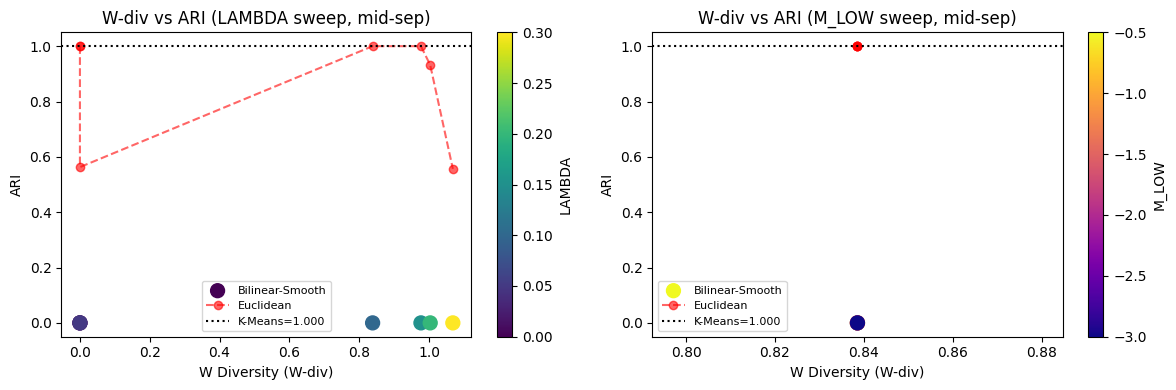

In [23]:
# ── W-div vs ARI 산점도 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# BETA_REP 스윕 결과
wdivs_br  = [r['wdiv'] for r in brep_results]
aris_sm_br = [r['aris']['Bilinear-Smooth'] for r in brep_results]
aris_eu_br = [r['aris']['Euclidean'] for r in brep_results]
brs        = [r['br'] for r in brep_results]

ax = axes[0]
sc = ax.scatter(wdivs_br, aris_sm_br, c=brs, cmap='viridis', s=100, zorder=3, label='Bilinear-Smooth')
ax.plot(wdivs_br, aris_eu_br, 'r--o', alpha=0.6, label='Euclidean')
ax.axhline(ARI_KM_MID, color='k', linestyle=':', label=f'K-Means={ARI_KM_MID:.3f}')
plt.colorbar(sc, ax=ax, label='LAMBDA')
ax.set_xlabel('W Diversity (W-div)')
ax.set_ylabel('ARI')
ax.set_title('W-div vs ARI (LAMBDA sweep, mid-sep)')
ax.legend(fontsize=8)

# M_LOW 스윕 결과
wdivs_ml   = [r['wdiv'] for r in mlow_results]
aris_sm_ml = [r['aris']['Bilinear-Smooth'] for r in mlow_results]
aris_eu_ml = [r['aris']['Euclidean'] for r in mlow_results]
mls        = [r['ml'] for r in mlow_results]

ax = axes[1]
sc2 = ax.scatter(wdivs_ml, aris_sm_ml, c=mls, cmap='plasma', s=100, zorder=3, label='Bilinear-Smooth')
ax.plot(wdivs_ml, aris_eu_ml, 'r--o', alpha=0.6, label='Euclidean')
ax.axhline(ARI_KM_MID, color='k', linestyle=':', label=f'K-Means={ARI_KM_MID:.3f}')
plt.colorbar(sc2, ax=ax, label='M_LOW')
ax.set_xlabel('W Diversity (W-div)')
ax.set_ylabel('ARI')
ax.set_title('W-div vs ARI (M_LOW sweep, mid-sep)')
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()


In [ ]:
# ── PCA 시각화: 최적 설정 mid-sep ──
aris_best, diag_best = run_aiso(X_mid, y_mid, BETA_REP=0.05, M_LOW=-2.0, verbose=True)

pca2  = PCA(n_components=2, random_state=42).fit(X_mid)
X_2d  = pca2.transform(X_mid)
Ag_2d = pca2.transform(diag_best['X_ag'])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
methods   = ['True Labels', 'Euclidean', 'Bilinear-Smooth', 'W-Direct']
pred_list = [y_mid,
             run_aiso(X_mid, y_mid, BETA_REP=0.05, M_LOW=-2.0, verbose=False)[0]['Euclidean'],
             run_aiso(X_mid, y_mid, BETA_REP=0.05, M_LOW=-2.0, verbose=False)[0]['Bilinear-Smooth'],
             run_aiso(X_mid, y_mid, BETA_REP=0.05, M_LOW=-2.0, verbose=False)[0]['W-Direct']]

for ax, title, pred in zip(axes, methods, pred_list):
    ari_val = adjusted_rand_score(y_mid, pred) if title != 'True Labels' else 1.0
    for c in range(N_CLUSTERS):
        mask = pred == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.5, s=25, label=f'C{c}')
    ax.scatter(Ag_2d[:, 0], Ag_2d[:, 1], c='black', marker='*', s=150, zorder=5)
    ax.set_title(f"{title}\nARI={ari_val:.4f}")
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()


TypeError: run_aiso() got an unexpected keyword argument 'BETA_REP'

: 

## 결과 해석 및 결론

### 관찰 포인트
1. **W-div ↑ → Bilinear↑?**: 상관관계 있으면 W collapse 해결이 핵심
2. **Euclidean ≈ K-Means**: AISO의 위치 수렴만으로도 K-Means 근접 가능?
3. **Bilinear > Euclidean 구간**: 존재하면 M 행렬이 구조 인코딩 성공

### 예상 시나리오
| 시나리오 | 관찰 | 결론 |
|---------|------|------|
| A | Bilinear > Euclidean 구간 존재 | M이 유효 정보 인코딩 — collapse만 해결하면 됨 |
| B | Euclidean ≈ K-Means, Bilinear ≤ Euclidean | 위치 수렴이 충분, bilinear는 부가가치 없음 |
| C | 모든 AISO < K-Means (고분리에서도) | AISO 클러스터링 구조적 한계 — GNN 보조 역할이 본령 |

### AISO의 진짜 강점 재정의
- **클러스터링 모델**: K-Means의 강력한 대안이 되기 어려움 (Scenario B/C 가능성)
- **GNN 보조 샘플러**: Elliptic에서 +0.123 PR-AUC (PSO 대비) → 검증된 가치
- **Adapter 방향**: Active learning, confidence calibration — 탐색 가치 있음
